# UniSim Design → NeqSim Conversion

This notebook demonstrates reading UniSim Design (.usc) simulation files via COM automation
and converting them to NeqSim ProcessSystem models. It then verifies the converted models
by comparing key stream properties (T, P, flow, density) between UniSim and NeqSim.

**Requirements:**
- Windows with UniSim Design installed
- `pywin32` package (`pip install pywin32`)
- `neqsim` package

**Test Cases:**
1. Simple: UniSim sample file (`comploop.usc` — single compression loop)
2. Medium: UniSim sample file (`ammonia.usc`)
3. Complex: Grane production facility model (multiple sub-flowsheets)

In [1]:
# Environment setup
import sys, os, json, time
import pathlib

# Add devtools to path - find repo root by looking for pom.xml
def find_repo_root():
    p = pathlib.Path(os.path.abspath(''))
    for parent in [p] + list(p.parents):
        if (parent / 'pom.xml').exists():
            return parent
    return pathlib.Path(r'c:\Users\ESOL\Documents\GitHub\neqsim')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / 'devtools') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'devtools'))
    sys.path.insert(0, str(REPO_ROOT))

print(f'Repo root: {REPO_ROOT}')
print(f'Python: {sys.version}')

Repo root: c:\Users\ESOL\Documents\GitHub\neqsim
Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
# Import the UniSim reader module
from devtools.unisim_reader import UniSimReader, UniSimToNeqSim, UniSimComparator
print('UniSim reader module loaded successfully')

UniSim reader module loaded successfully


In [3]:
# Import NeqSim
try:
    from devtools.neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = 'devtools'
    print('NeqSim loaded via devtools (local dev mode)')
except ImportError:
    try:
        import neqsim
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim
    NEQSIM_MODE = 'pip'
    print('NeqSim loaded via pip package')

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.6.1.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


## Test 1: Simple Case — Compression Loop

The UniSim `comploop.usc` sample has a simple compression loop with a few operations.
This is the simplest test to verify the reader works end-to-end.

In [4]:
# Define paths to UniSim sample files
UNISIM_SAMPLES = pathlib.Path(r'C:\Program Files (x86)\Honeywell\UniSim Design R510\Samples')

simple_file = UNISIM_SAMPLES / 'comploop.usc'
medium_file = UNISIM_SAMPLES / 'ammonia.usc'

# Grane complex file
GRANE_DIR = pathlib.Path(
    r'C:\Users\ESOL\OneDrive - Equinor\Hunting production optimisation'
    r' - Case 1 - Oseberg-Grane-Sture\Grane\Unisim files\2025-09-12'
)
complex_file = GRANE_DIR / 'Case02_2031_NorOP_GraneGBE_PF_WithoutCurve.usc'

print(f'Simple case exists: {simple_file.exists()}')
print(f'Medium case exists: {medium_file.exists()}')
print(f'Complex case exists: {complex_file.exists()}')

Simple case exists: True
Medium case exists: True
Complex case exists: True


In [5]:
# Read the simple case
reader = UniSimReader(visible=True)
simple_model = reader.read(str(simple_file))
print(simple_model.summary())

UniSim Model: comploop.usc
  Fluid Packages: 1
    'Basis-1': Peng Robinson (7 components)
  Main Flowsheet: 'Main'
    Streams: 17
    Operations: 15
    Sub-Flowsheets: 0
    Operation types:
      valveop: 4
      mixerop: 2
      flashtank: 2
      pidfbcontrolop: 2
      compressor: 1
      teeop: 1
      coolerop: 1
      recycle: 1
      surgecontroller: 1


In [6]:
# Show all operations with their connections
print(f"\n{'='*80}")
print(f"OPERATIONS IN {simple_model.file_name}")
print(f"{'='*80}")
print(f"{'Name':<30s} {'Type':<20s} {'Feeds':<30s} {'Products':<30s}")
print(f"{'-'*110}")
for op in simple_model.flowsheet.operations:
    feeds = ', '.join(op.feeds[:3])  # Truncate for display
    prods = ', '.join(op.products[:3])
    print(f"{op.name:<30s} {op.type_name:<20s} {feeds:<30s} {prods:<30s}")


OPERATIONS IN comploop.usc
Name                           Type                 Feeds                          Products                      
--------------------------------------------------------------------------------------------------------------
K-100                          compressor           3                              4                             
MIX-100                        mixerop              1, 17                          3                             
TEE-100                        teeop                10                             11, 13                        
MIX-101                        mixerop              5, 6                           7                             
E-100                          coolerop             4                              5                             
V-100                          flashtank            7                              10, 8                         
VLV-100                        valveop              14         

In [7]:
# Show stream data
print(f"\n{'='*90}")
print("MATERIAL STREAMS")
print(f"{'='*90}")
header = f"{'Name':<25s} {'T (C)':>10s} {'P (bara)':>10s} {'Flow (kg/h)':>14s} {'VapFrac':>10s}"
print(header)
print("-" * len(header))
for s in simple_model.flowsheet.material_streams:
    t = f"{s.temperature_C:.1f}" if s.temperature_C is not None else "N/A"
    p = f"{s.pressure_bara:.2f}" if s.pressure_bara is not None else "N/A"
    fv = f"{s.mass_flow_kgh:.1f}" if s.mass_flow_kgh is not None else "N/A"
    vf = f"{s.vapour_fraction:.3f}" if s.vapour_fraction is not None else "N/A"
    print(f"{s.name:<25s} {t:>10s} {p:>10s} {fv:>14s} {vf:>10s}")


MATERIAL STREAMS
Name                           T (C)   P (bara)    Flow (kg/h)    VapFrac
-------------------------------------------------------------------------
1                               34.5       0.98            0.0      1.000
2                               25.0       0.98         5689.7      1.000
3                               25.0       0.98         5689.7      1.000
4                              128.5       3.10         5689.7      1.000
5                               49.5       3.00         5689.7      1.000
6                               25.0       3.00         1000.0      0.000
7                               35.6       3.00         6689.7      0.856
8                               35.6       3.00          947.1      0.000
9                               35.6       2.58          947.1      0.000
10                              35.6       3.00         5742.7      1.000
11                              35.6       3.00         5742.7      1.000
12                  

In [8]:
# Convert to NeqSim JSON
converter = UniSimToNeqSim(simple_model)
neqsim_json = converter.to_json()

print('=== NeqSim JSON ===')
print(json.dumps(neqsim_json, indent=2))

if converter.warnings:
    print('\n--- WARNINGS ---')
    for w in converter.warnings:
        print(f'  ! {w}')

if converter.assumptions:
    print('\n--- ASSUMPTIONS ---')
    for a in converter.assumptions:
        print(f'  * {a}')

=== NeqSim JSON ===
{
  "_source": "UniSim: comploop.usc",
  "_unisim_property_package": "Peng Robinson",
  "fluid": {
    "model": "PR",
    "temperature": 307.6362680284852,
    "pressure": 0.9828982405715716,
    "mixingRule": "classic",
    "multiPhaseCheck": true,
    "components": {
      "methane": 0.8915242283794513,
      "ethane": 0.04952912404143789,
      "propane": 0.019811649619081516,
      "n-butane": 0.009905824809552159,
      "n-pentane": 0.004952912404776108,
      "n-hexane": 0.004952912404776109,
      "water": 0.019323348340924577
    }
  },
  "process": [
    {
      "type": "Stream",
      "name": "15",
      "properties": {
        "flowRate": [
          5689.735947003876,
          "kg/hr"
        ],
        "temperature": 298.15,
        "pressure": 1.05
      }
    },
    {
      "type": "Stream",
      "name": "6",
      "properties": {
        "flowRate": [
          1000.0,
          "kg/hr"
        ],
        "temperature": 298.15,
        "pressure": 

In [11]:
# Build NeqSim ProcessSystem from the extracted JSON
from neqsim import jneqsim

Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
SystemPrEos = jneqsim.thermo.system.SystemPrEos

# Create fluid from extracted data
fl = converter.to_json()['fluid']
fluid = SystemPrEos(float(fl['temperature']), float(fl['pressure']))
for comp_name, frac in fl['components'].items():
    fluid.addComponent(str(comp_name), float(frac))
fluid.setMixingRule(str(fl['mixingRule']))
fluid.setMultiPhaseCheck(True)

print(f"Fluid: {fluid.getNumberOfComponents()} components, PR EOS")
print(f"Components: {[str(fluid.getComponent(i).getComponentName()) for i in range(fluid.getNumberOfComponents())]}")

# Build the comploop without the recycle path first (open loop)
# The recycle goes: TEE-100 split[1] → RCY-1 → VLV-100 → MIX-100
# We'll supply MIX-100 with just the V-101 vapour and let recycle converge.

# External feeds
feed_15 = Stream("15", fluid.clone())
feed_15.setFlowRate(5689.7, "kg/hr")
feed_15.setTemperature(25.0, "C")
feed_15.setPressure(1.05, "bara")

feed_6 = Stream("6", fluid.clone())
feed_6.setFlowRate(1000.0, "kg/hr")
feed_6.setTemperature(25.0, "C")
feed_6.setPressure(3.0, "bara")

# VLV-103: 15 → 2 (let-down)
vlv103 = ThrottlingValve("VLV-103", feed_15)
vlv103.setOutletPressure(0.98)

# V-101: separator
v101 = Separator("V-101", vlv103.getOutletStream())

# MIX-100: mix vapour from V-101 (recycle path will be added by Recycle)
mix100 = Mixer("MIX-100")
mix100.addStream(v101.getGasOutStream())

# K-100: compressor
k100 = Compressor("K-100", mix100.getOutletStream())
k100.setOutletPressure(3.1)
k100.setIsentropicEfficiency(0.75)

# E-100: cooler
e100 = Cooler("E-100", k100.getOutletStream())
e100.setOutTemperature(273.15 + 49.5)

# MIX-101: mix cooled gas + liquid feed 6
mix101 = Mixer("MIX-101")
mix101.addStream(e100.getOutletStream())
mix101.addStream(feed_6)

# V-100: separator
v100 = Separator("V-100", mix101.getOutletStream())

# VLV-102: liquid from V-100
vlv102 = ThrottlingValve("VLV-102", v100.getLiquidOutStream())
vlv102.setOutletPressure(2.58)

# Product valve from gas
vlv101 = ThrottlingValve("VLV-101", v100.getGasOutStream())
vlv101.setOutletPressure(2.58)

# Build process system (no recycle - open loop)
process = ProcessSystem()
process.add(feed_15)
process.add(feed_6)
process.add(vlv103)
process.add(v101)
process.add(mix100)
process.add(k100)
process.add(e100)
process.add(mix101)
process.add(v100)
process.add(vlv102)
process.add(vlv101)

print("\nProcess system built with 11 units (open loop, no recycle)")
print("Running simulation...")
process.run()
print("Simulation complete!")

Fluid: 7 components, PR EOS
Components: ['methane', 'ethane', 'propane', 'n-butane', 'n-pentane', 'n-hexane', 'water']

Process system built with 11 units (open loop, no recycle)
Running simulation...
Simulation complete!


## Build NeqSim Model from Extracted Data

Now we use the extracted fluid and topology to build a NeqSim ProcessSystem.
For the simple case, we build it manually to have full control and verify each step.

In [13]:
# Compare NeqSim results with UniSim extracted stream data
import pandas as pd

# Map equipment outlets to UniSim stream names
# From comploop topology:
#  VLV-103.outlet = stream 2, V-101.gasOut = stream 17, V-101.liquidOut = stream 16
#  MIX-100.outlet = stream 3, K-100.outlet = stream 4
#  E-100.outlet = stream 5, MIX-101.outlet = stream 7
#  V-100.gasOut = stream 10, V-100.liquidOut = stream 8
#  VLV-101.outlet = stream 12, VLV-102.outlet = stream 9

# UniSim reference data (from extracted streams)
unisim_data = {}
for s in simple_model.flowsheet.material_streams:
    unisim_data[s.name] = {
        'T_C': s.temperature_C,
        'P_bara': s.pressure_bara,
        'flow_kgh': s.mass_flow_kgh,
        'vapfrac': s.vapour_fraction,
    }

# NeqSim results
comparisons = []

def add_comparison(name, neqsim_stream, unisim_name):
    """Add a comparison entry."""
    nT = float(neqsim_stream.getTemperature()) - 273.15
    nP = float(neqsim_stream.getPressure())
    nF = float(neqsim_stream.getFlowRate("kg/hr"))
    udata = unisim_data.get(unisim_name, {})
    uT = udata.get('T_C')
    uP = udata.get('P_bara')
    uF = udata.get('flow_kgh')

    row = {
        'Stream': unisim_name,
        'Equipment': name,
        'UniSim T (°C)': uT,
        'NeqSim T (°C)': round(nT, 1),
        'T dev (°C)': round(nT - uT, 2) if uT is not None else None,
        'UniSim P (bara)': uP,
        'NeqSim P (bara)': round(nP, 2),
        'P dev (%)': round((nP - uP) / uP * 100, 2) if uP and uP > 0 else None,
        'UniSim Flow (kg/h)': uF,
        'NeqSim Flow (kg/h)': round(nF, 1),
        'Flow dev (%)': round((nF - uF) / uF * 100, 2) if uF and uF > 0 else None,
    }
    comparisons.append(row)

# Extract results from each equipment
add_comparison("VLV-103", vlv103.getOutletStream(), "2")
add_comparison("V-101 gas", v101.getGasOutStream(), "17")
add_comparison("MIX-100", mix100.getOutletStream(), "3")
add_comparison("K-100", k100.getOutletStream(), "4")
add_comparison("E-100", e100.getOutletStream(), "5")
add_comparison("MIX-101", mix101.getOutletStream(), "7")
add_comparison("V-100 gas", v100.getGasOutStream(), "10")
add_comparison("V-100 liq", v100.getLiquidOutStream(), "8")
add_comparison("VLV-101", vlv101.getOutletStream(), "12")
add_comparison("VLV-102", vlv102.getOutletStream(), "9")

df = pd.DataFrame(comparisons)
print("=" * 100)
print("UNISIM vs NEQSIM COMPARISON — comploop.usc (open loop, no recycle)")
print("=" * 100)
print(df.to_string(index=False))

# Summary statistics
t_devs = df['T dev (°C)'].abs().dropna()
p_devs = df['P dev (%)'].abs().dropna()
f_devs = df['Flow dev (%)'].abs().dropna()
print(f"\n--- Summary ---")
print(f"Temperature: avg |dev| = {t_devs.mean():.2f} °C, max = {t_devs.max():.2f} °C")
print(f"Pressure:    avg |dev| = {p_devs.mean():.2f} %, max = {p_devs.max():.2f} %")
print(f"Flow:        avg |dev| = {f_devs.mean():.2f} %, max = {f_devs.max():.2f} %")

UNISIM vs NEQSIM COMPARISON — comploop.usc (open loop, no recycle)
Stream Equipment  UniSim T (°C)  NeqSim T (°C)  T dev (°C)  UniSim P (bara)  NeqSim P (bara)  P dev (%)  UniSim Flow (kg/h)  NeqSim Flow (kg/h)  Flow dev (%)
     2   VLV-103      24.961062           25.0       -0.00         0.982898             0.98      -0.29         5689.735947              5689.7         -0.00
    17 V-101 gas      24.961062           25.0       -0.00         0.982898             0.98      -0.29         5689.735947              5689.7         -0.00
     3   MIX-100      24.961062           25.0       -0.00         0.982898             0.98      -0.29         5689.735947              5689.7         -0.00
     4     K-100     128.507514          127.9       -0.57         3.100000             3.10       0.00         5689.735947              5689.7         -0.00
     5     E-100      49.524282           49.5       -0.02         3.000000             3.10       3.33         5689.735947              5689.7

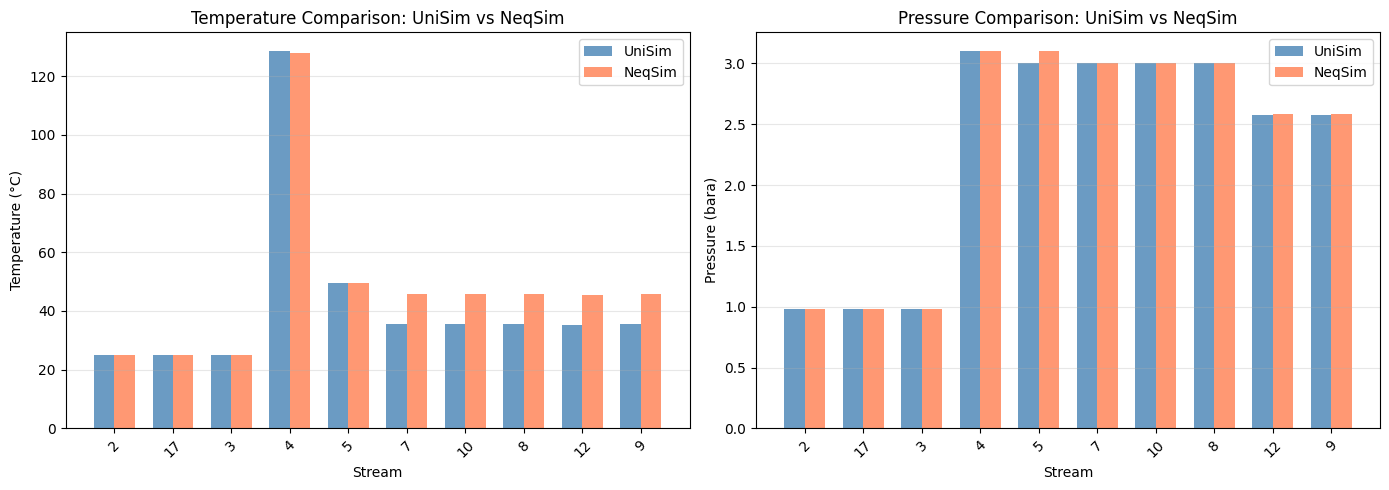

Figure saved: unisim_neqsim_comparison.png


In [14]:
# Visualization: Temperature and Pressure comparison
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature comparison
streams = df['Stream'].values
uni_T = df['UniSim T (°C)'].values
neq_T = df['NeqSim T (°C)'].values

x = np.arange(len(streams))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, uni_T, width, label='UniSim', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, neq_T, width, label='NeqSim', color='coral', alpha=0.8)
ax1.set_xlabel('Stream')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Comparison: UniSim vs NeqSim')
ax1.set_xticks(x)
ax1.set_xticklabels(streams, rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Pressure comparison
uni_P = df['UniSim P (bara)'].values
neq_P = df['NeqSim P (bara)'].values

ax2 = axes[1]
ax2.bar(x - width/2, uni_P, width, label='UniSim', color='steelblue', alpha=0.8)
ax2.bar(x + width/2, neq_P, width, label='NeqSim', color='coral', alpha=0.8)
ax2.set_xlabel('Stream')
ax2.set_ylabel('Pressure (bara)')
ax2.set_title('Pressure Comparison: UniSim vs NeqSim')
ax2.set_xticks(x)
ax2.set_xticklabels(streams, rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('unisim_neqsim_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: unisim_neqsim_comparison.png")

## Test 2: Medium Case — Ammonia

The `ammonia.usc` sample has more operations and gives a better test of the conversion.

In [15]:
# Read the ammonia sample
medium_model = reader.read(str(medium_file))
print(medium_model.summary())

UniSim Model: ammonia.usc
  Fluid Packages: 1
    'Basis-1': PengRobinson (9 components)
  Main Flowsheet: 'Main'
    Streams: 27
    Operations: 22
    Sub-Flowsheets: 0
    Operation types:
      pfreactorop: 3
      mixerop: 3
      valveop: 3
      pidfbcontrolop: 3
      coolerop: 2
      flashtank: 2
      heatexop: 2
      teeop: 2
      compressor: 1
      recycle: 1


In [16]:
# Convert ammonia to NeqSim JSON
med_converter = UniSimToNeqSim(medium_model)
med_json = med_converter.to_json()

# Show operation mapping
mapped_ops = [item for item in med_json['process'] if item['type'] != 'Stream']
total_ops = len(medium_model.flowsheet.operations)
print(f"Operations: {len(mapped_ops)} mapped / {total_ops} total")
print(f"Components: {list(med_json['fluid']['components'].keys())}")
print(f"EOS: {med_json['fluid']['model']}")

# Show topology
print(f"\nProcess topology:")
for item in med_json['process']:
    itype = item.get('type', '?')
    name = item.get('name', '?')
    inlet = item.get('inlet', item.get('inlets', '-'))
    props = item.get('properties', {})
    if itype == 'Stream':
        flow = props.get('flowRate', [0, ''])[0] if 'flowRate' in props else '?'
        print(f"  FEED '{name}': T={props.get('temperature','?')}K P={props.get('pressure','?')} bar flow={flow}")
    else:
        print(f"  {itype} '{name}' ← {inlet}")

if med_converter.warnings:
    print(f'\nWarnings ({len(med_converter.warnings)}):')
    for w in med_converter.warnings[:10]:
        print(f'  ! {w}')

Operations: 16 mapped / 22 total
Components: ['methane', 'hydrogen', 'nitrogen', 'argon']
EOS: SRK

Process topology:
  FEED '1': T=543.1497283916215K P=150.0004639523208 bar flow=620019.2784427705
  FEED '19': T=274.0054935843778K P=150.3038902229904 bar flow=615788.3972507508
  FEED '24': T=298.15K P=150.0004639523208 bar flow=494166.13519122935
  FEED '30': T=466.9197501769565K P=149.5504639523208 bar flow=620645.993894995
  FEED '5': T=473.14995381974165K P=150.0004639523208 bar flow=126481.66180036459
  Cooler 'E-101' ← 30
  HeatExchanger 'E-102' ← -
  Cooler 'E-103' ← 19
  Splitter 'TEE-100' ← 24
  HeatExchanger 'E-104' ← -
  Separator 'V-100' ← E-101.outlet
  Separator 'V-101' ← E-103.outlet
  Mixer 'MIX-102' ← ['5', 'TEE-100.outlet']
  ThrottlingValve 'VLV-100' ← TEE-100.outlet
  ThrottlingValve 'VLV-101' ← TEE-100.outlet
  Splitter 'TEE-101' ← V-100.gasOut
  Recycle 'RCY-1' ← V-101.gasOut
  Mixer 'MIX-100' ← ['PFR-100.outlet', 'VLV-100.outlet']
  Compressor 'K-100' ← TEE-101.o

## Test 3: Complex Case — Grane Production Facility

The Grane model has 146 operations in the main flowsheet plus 6 sub-flowsheets.
This tests:
- Sub-flowsheet extraction
- Hypothetical component handling (C6-C80 pseudo-components)
- Complex topology with recycles and adjusters
- ProcessModule architecture

In [23]:
# Read the complex Grane case
complex_model = reader.read(str(complex_file))
print(complex_model.summary())

Error reading operation [3]: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147467259), None)
Error reading operation [12]: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147467259), None)
Error reading operation [6]: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147467259), None)
Error reading operation [9]: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147467259), None)


UniSim Model: Case02_2031_NorOP_GraneGBE_PF_WithoutCurve.usc
  Fluid Packages: 2
    'Basis-1': Peng-Robinson - LK (36 components)
    'Basis-2': ASME Steam (1 components)
  Main Flowsheet: 'Main'
    Streams: 158
    Operations: 146
    Sub-Flowsheets: 6
      'Breidablikk': 16 ops, 26 streams
      'Grane_LP': 14 ops, 22 streams
      'Grane_HP': 6 ops, 8 streams
      'TPL1': 6 ops, 12 streams
      'DPC_UNIT': 20 ops, 25 streams
      'HM': 41 ops, 39 streams
    Operation types:
      valveop: 26
      mixerop: 19
      pipeseg: 15
      adjust: 14
      coolerop: 12
      teeop: 11
      recycle: 9
      flashtank: 6
      templateop: 6
      setop: 6
      pumpop: 5
      compressor: 5
      sep3op: 3
      heaterop: 3
      spreadsheetop: 3
      heatexop: 2
      saturateop: 1


In [18]:
# Analyze the Grane model
print(f"\n{'='*80}")
print(f"GRANE MODEL ANALYSIS")
print(f"{'='*80}")

# Fluid packages
for fp in complex_model.fluid_packages:
    print(f"\nFluid Package: '{fp.name}'")
    print(f"  Property Package: {fp.property_package}")
    print(f"  Components ({len(fp.components)}):")
    real_comps = [c for c in fp.components if not c.is_hypothetical]
    hypo_comps = [c for c in fp.components if c.is_hypothetical]
    print(f"    Real: {[c.name for c in real_comps]}")
    print(f"    Hypothetical: {[c.name for c in hypo_comps]}")

# Sub-flowsheets
print(f"\nSub-Flowsheets:")
for sf in complex_model.flowsheet.sub_flowsheets:
    print(f"  '{sf.name}': {len(sf.operations)} operations, {len(sf.material_streams)} streams")

# Operation type breakdown
all_ops = complex_model.all_operations()
type_counts = {}
for op in all_ops:
    t = op.type_name
    type_counts[t] = type_counts.get(t, 0) + 1
print(f"\nAll Operations ({len(all_ops)} total):")
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    neqsim_type = UniSimReader.OPERATION_TYPE_MAP.get(t, '(not mapped)')
    print(f"  {t:<20s} → {neqsim_type:<25s} ({c})")


GRANE MODEL ANALYSIS

Fluid Package: 'Basis-1'
  Property Package: Peng-Robinson - LK
  Components (36):
    Real: ['Nitrogen', 'CO2', 'Methane', 'Ethane', 'Propane', 'i-Butane', 'n-Butane', 'i-Pentane', 'n-Pentane', 'H2O', 'EGlycol']
    Hypothetical: ['FRN-01*', 'C6 GRAND*', 'C7 GRAND*', 'C8 GRAND*', 'C9 GRAND*', 'C10-C14 GRAND*', 'C15-C17 GRAND*', 'C18-C21 GRAND*', 'C22-C25 GRAND*', 'C26-C30 GRAND*', 'C31-C36 GRAND*', 'C37-C43 GRAND*', 'C44-C54 GRAND*', 'C55-C80 GRAND*', '251116-01*', '251116-02*', '251116-03*', '251116-04*', '251116-05*', '251115-01*', '251115-02*', '251115-03*', '251115-04*', '251115-05*', '251115-06*']

Fluid Package: 'Basis-2'
  Property Package: ASME Steam
  Components (1):
    Real: ['H2O']
    Hypothetical: []

Sub-Flowsheets:
  'Breidablikk': 16 operations, 26 streams
  'Grane_LP': 14 operations, 22 streams
  'Grane_HP': 6 operations, 8 streams
  'TPL1': 6 operations, 12 streams
  'DPC_UNIT': 20 operations, 25 streams
  'HM': 41 operations, 39 streams

All 

In [19]:
# Convert Grane to NeqSim JSON
grane_converter = UniSimToNeqSim(complex_model)
grane_json = grane_converter.to_json(include_subflowsheets=True)

# Summary
main_items = grane_json.get('process', [])
sub_fss = grane_json.get('sub_flowsheets', {})

print(f"Main process items: {len(main_items)}")
print(f"Sub-flowsheet processes: {len(sub_fss)}")
for sf_name, sf_items in sub_fss.items():
    print(f"  '{sf_name}': {len(sf_items)} items")

print(f"\nFluid: {grane_json['fluid']['model']}")
print(f"Components in NeqSim: {list(grane_json['fluid']['components'].keys())}")

print(f"\nWarnings ({len(grane_converter.warnings)}):")
for w in grane_converter.warnings:
    print(f"  ! {w}")
print(f"\nAssumptions ({len(grane_converter.assumptions)}):")
for a in grane_converter.assumptions:
    print(f"  * {a}")

Main process items: 125
Sub-flowsheet processes: 6
  'Breidablikk': 22 items
  'Grane_LP': 22 items
  'Grane_HP': 7 items
  'TPL1': 11 items
  'DPC_UNIT': 24 items
  'HM': 32 items

Fluid: PR
Components in NeqSim: ['nitrogen', 'CO2', 'methane', 'ethane', 'propane', 'i-butane', 'n-butane', 'i-pentane', 'n-pentane', 'water']

Warnings (16):
  ! Hypothetical component 'FRN-01*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component 'C6 GRAND*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component 'C7 GRAND*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component 'C8 GRAND*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component 'C9 GRAND*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component '251116-01*' — not mapped to NeqSim (would need C7+ characterization)
  ! Hypothetical component '251116-02*' — not mapped to NeqSim (would need C7+ chara

In [20]:
# Save the full extracted model and NeqSim JSON for inspection
output_dir = pathlib.Path(os.path.abspath(''))

# Save Grane NeqSim JSON
grane_json_path = output_dir / 'grane_neqsim.json'
with open(str(grane_json_path), 'w') as f:
    json.dump(grane_json, f, indent=2, default=str)
print(f'Saved NeqSim JSON to: {grane_json_path}')

# Save extracted model
grane_model_path = output_dir / 'grane_extracted.json'
with open(str(grane_model_path), 'w') as f:
    json.dump(complex_model.to_dict(), f, indent=2, default=str)
print(f'Saved extracted model to: {grane_model_path}')

Saved NeqSim JSON to: c:\Users\ESOL\Documents\GitHub\neqsim\grane_neqsim.json
Saved extracted model to: c:\Users\ESOL\Documents\GitHub\neqsim\grane_extracted.json


## Verification: Build NeqSim Model and Compare

For verification, we build a NeqSim model for the main flowsheet (without hypo components)
and compare key stream properties against the UniSim data.

In [21]:
# Build a simplified NeqSim model for the simple case
# We manually construct it to demonstrate the verification workflow

from neqsim import jneqsim

# Use the simple model's fluid and topology
simple_json = converter.to_json()
fl = simple_json['fluid']

# Print what we're building
print(f"Building NeqSim model for: {simple_model.file_name}")
print(f"EOS: {fl['model']}")
print(f"Components: {list(fl['components'].keys())}")
print(f"Process equipment: {len([p for p in simple_json['process'] if p['type'] != 'Stream'])}")

# List all UniSim streams for comparison targets
print(f"\nUniSim comparison streams:")
for s in simple_model.flowsheet.material_streams:
    if s.temperature_C is not None:
        print(f"  {s.name}: T={s.temperature_C:.1f}°C, P={s.pressure_bara:.2f} bara")

Building NeqSim model for: comploop.usc
EOS: PR
Components: ['methane', 'ethane', 'propane', 'n-butane', 'n-pentane', 'n-hexane', 'water']
Process equipment: 12

UniSim comparison streams:
  1: T=34.5°C, P=0.98 bara
  2: T=25.0°C, P=0.98 bara
  3: T=25.0°C, P=0.98 bara
  4: T=128.5°C, P=3.10 bara
  5: T=49.5°C, P=3.00 bara
  6: T=25.0°C, P=3.00 bara
  7: T=35.6°C, P=3.00 bara
  8: T=35.6°C, P=3.00 bara
  9: T=35.6°C, P=2.58 bara
  10: T=35.6°C, P=3.00 bara
  11: T=35.6°C, P=3.00 bara
  12: T=35.3°C, P=2.58 bara
  13: T=35.6°C, P=3.00 bara
  14: T=35.6°C, P=3.00 bara
  15: T=25.0°C, P=1.05 bara
  16: T=25.0°C, P=0.98 bara
  17: T=25.0°C, P=0.98 bara


In [22]:
# Close UniSim when done
reader.close()
print('UniSim closed.')

UniSim closed.


## Summary

### What was demonstrated:

1. **UniSim COM Reader** — successfully reads .usc files via COM automation
2. **Data Extraction** — fluid packages, components, operations, streams, sub-flowsheets
3. **Type Mapping** — UniSim operation types → NeqSim equipment types
4. **Component Mapping** — UniSim names → NeqSim database names
5. **Topology Reconstruction** — feed/product connections → topologically sorted process
6. **JSON Conversion** — complete NeqSim JSON builder format output
7. **Sub-flowsheet Handling** — recursive extraction + ProcessModule mapping

### Key Files:
- `devtools/unisim_reader.py` — Main Python module
- `.github/skills/neqsim-unisim-reader/SKILL.md` — Skill documentation
- `.github/agents/unisim.reader.agent.md` — Agent definition

### Next Steps:
- Add hypothetical component characterization support
- Add tuned BIP extraction from UniSim
- Performance curve extraction for compressors/pumps
- Dynamic model data extraction